# 2D Control Matrix Optimization: Time-Wealth Policy

This notebook implements a gradient descent optimizer for a 2D control matrix that responds to both time (age) and wealth.

## Key Features:
- **Bilinear interpolation** across time and wealth dimensions
- **Gradient-based optimization** using PyTorch automatic differentiation
- **Flexible policy representation** with configurable grid resolution
- **Consumption-aware simulation** with inflation and real decline in needs

## Method Overview:
The control matrix C(t, W) defines stock allocation as a function of both:
- **Time (t)**: Years from start of retirement
- **Wealth (W)**: Current portfolio value

We optimize the control matrix nodes, then use bilinear interpolation to get allocations for any (t, W) pair.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys
sys.path.append('..')  # Add Code directory to path

# Import utils package
from utils import (
    CholeskyBootstrapReturns,
    ControlMatrixPolicy,
    load_historical_returns,
    sample_without_replacement,
    SigmoidWealthPenalty,
    CRRAUtility,
    ConstantInflation,
    simulate_wealth_trajectory,
)

# Import new modular spending components
from utils.spending import (
    FloorCeilingRule,
    NoIncome,
    SpendingPolicy,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

torch.cuda.is_available()

True

In [2]:
# Check CUDA availability and configuration
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current Device: {torch.cuda.current_device()}")
else:
    print("CUDA not available - will use CPU")

CUDA Available: True
CUDA Device: NVIDIA GeForce RTX 3070
CUDA Version: 13.0
Number of GPUs: 1
Current Device: 0


## 1. Load Historical Returns

We'll use the same return data as the age-based optimization.

In [3]:
# Load historical returns using utils
try:
    yearly_returns, yearly_mean, yearly_cov = load_historical_returns(
        source="sallypy",
        bonds_ticker="BMK0017",
        stocks_ticker="BMK0188"
    )
except:
    # Fallback to CSV if sallypy not available
    print("Loading from CSV...")
    yearly_returns, yearly_mean, yearly_cov = load_historical_returns(
        source="csv",
        csv_path="../WIP/returns.csv"
    )

print(f"Mean annual returns:\n{yearly_mean}")
print(f"\nCovariance matrix:\n{yearly_cov}")

Mean annual returns:
Bonds     0.076926
Stocks    0.112436
dtype: float64

Covariance matrix:
           Bonds    Stocks
Bonds   0.003535  0.000413
Stocks  0.000413  0.041097


## 2. Simulation Function

Uses `simulate_wealth_trajectory` from utils with `ControlMatrixPolicy` and `FloorCeilingSpending` policies.

In [ ]:
def simulate_wealth_with_control_matrix(
    simulated_returns: torch.Tensor,
    control_matrix: torch.Tensor,
    initial_wealth: float,
    min_consumption_real: float,
    consumption_rate: float,
    max_wealth: float,
    inflation: float = 0.03,
    real_decline_rate: float = 0.02,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Simulate wealth trajectories with 2D control matrix policy.
    
    Refactored to use simulate_wealth_trajectory from utils.simulation module.
    Uses ControlMatrixPolicy and new modular spending architecture.
    
    Parameters
    ----------
    simulated_returns : torch.Tensor
        n x s x 2 tensor of simulated returns [bonds, stocks]
    control_matrix : torch.Tensor
        (n_time_nodes, n_wealth_nodes) tensor of stock allocations
    initial_wealth : float
        Starting wealth
    min_consumption_real : float
        Minimum consumption in real terms at year 0
    consumption_rate : float
        Percentage of wealth to consume (e.g., 0.06 for 6%)
    max_wealth : float
        Maximum wealth bound for control matrix
    inflation : float
        Annual inflation rate
    real_decline_rate : float
        Annual decline in real consumption floor
    
    Returns
    -------
    tuple[torch.Tensor, torch.Tensor]
        (wealth, consumption) - Both as n x (s+1) and n x s tensors
    """
    s = simulated_returns.shape[1]  # number of time steps
    
    # Create allocation policy using ControlMatrixPolicy from utils
    allocation_policy = ControlMatrixPolicy(
        control_matrix=control_matrix,
        n_timesteps=s,
        max_wealth=max_wealth
    )
    
    # Create spending policy using new modular architecture:
    # - FloorCeilingRule: 6% of wealth with declining floor
    # - NoIncome: No external income sources
    # - SpendingPolicy: Combines rule + income, applies wealth constraints
    spending_rule = FloorCeilingRule(
        rate=consumption_rate,
        floor_real=min_consumption_real,
        decline_rate=real_decline_rate,
        inflation=ConstantInflation(inflation)
    )
    
    spending_policy = SpendingPolicy(
        spending=spending_rule,
        income=NoIncome()
    )
    
    # Use simulate_wealth_trajectory from utils.simulation
    wealth, consumption = simulate_wealth_trajectory(
        returns=simulated_returns,
        allocation_policy=allocation_policy,
        spending_policy=spending_policy,
        initial_wealth=initial_wealth
    )
    
    return wealth, consumption

### Spending Policy

**Rule:** 6% of current wealth with floor constraint
- **Rate:** 6% of current wealth per year
- **Floor:** $48,300 (No Frills Couple - Provincial tier)
- **Floor decline:** 2% per year in real terms
- **Income:** No external income sources

This policy ensures the household consumes at least the no frills couple budget, even if 6% of wealth falls below that threshold.

## 3. Optimization Setup

In [5]:
# Simulation parameters
N_SIMULATIONS = 10000   # Number of Monte Carlo simulations
BATCHES = 10            # Number of batches
S_TIMESTEPS = 40        # Number of years to simulate
INITIAL_WEALTH = 1000000 # Starting wealth

# Control matrix grid
N_TIME_NODES = 8        # Number of time nodes in control matrix
N_WEALTH_NODES = 30     # Number of wealth nodes in control matrix
MAX_WEALTH = 1500000    # Maximum wealth bound for grid

# Consumption parameters
MIN_CONSUMPTION_REAL = 48300  # No frills couple (provincial)
CONSUMPTION_RATE = 0.06       # 6% of wealth per year
INFLATION = 0.03              # 3% annual inflation
REAL_DECLINE_RATE = 0.02      # 2% decline in real needs per year

# Optimization parameters
SMOOTHNESS_WEIGHT = 0.001     # Penalty for allocation changes
LEARNING_RATE = 0.005          # Initial learning rate
N_ITERATIONS = 2000           # Number of optimization iterations

# PyTorch device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
# Generate simulated returns using CholeskyBootstrapReturns from utils
returns_generator = CholeskyBootstrapReturns(yearly_mean, yearly_cov)
mc_returns = torch.tensor(
    returns_generator.generate(
        n_simulations=N_SIMULATIONS*BATCHES,
        n_timesteps=S_TIMESTEPS
    ),
    dtype=torch.float32,
    device=DEVICE
)

print(f"Simulated returns shape: {mc_returns.shape}")
print(f"Mean bond return: {mc_returns[:, :, 0].mean():.4f}")
print(f"Mean stock return: {mc_returns[:, :, 1].mean():.4f}")

Simulated returns shape: torch.Size([100000, 40, 2])
Mean bond return: 0.0769
Mean stock return: 0.1124


In [7]:
# Initialize control matrix
# Start with a simple age-based decline: high stocks early, declining over time
# And wealth-responsive: higher stocks for higher wealth (more risk capacity)

time_gradient = np.linspace(1, 1, N_TIME_NODES)
wealth_gradient = np.linspace(1, 1, N_WEALTH_NODES)

# Create initial matrix as outer product (time effect × wealth effect)
initial_matrix = np.outer(time_gradient, wealth_gradient)

control_matrix = torch.tensor(
    initial_matrix,
    dtype=torch.float32,
    requires_grad=True,
    device=DEVICE
)

print(f"Control matrix shape: {control_matrix.shape}")
print(f"Initial control matrix:")
print(control_matrix.detach().cpu().numpy())

Control matrix shape: torch.Size([8, 30])
Initial control matrix:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]]


## 4. Optimization Loop

In [8]:
# Setup optimizer
optimizer = torch.optim.Adam([control_matrix], lr=LEARNING_RATE)

# Track optimization progress
cost_history = []
control_matrix_history = []
lr_history = []

# Adaptive learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=50
)

print("Starting optimization...\n")

for iteration in range(N_ITERATIONS):
    optimizer.zero_grad()
    
    # Sample returns for this iteration
    sampled_returns = sample_without_replacement(mc_returns, N_SIMULATIONS)
    
    # Simulate wealth and consumption
    wealth, consumption = simulate_wealth_with_control_matrix(
        simulated_returns=sampled_returns,
        control_matrix=control_matrix,
        initial_wealth=INITIAL_WEALTH,
        min_consumption_real=MIN_CONSUMPTION_REAL,
        consumption_rate=CONSUMPTION_RATE,
        max_wealth=MAX_WEALTH,
        inflation=INFLATION,  # Pass float, not ConstantInflation object
        real_decline_rate=REAL_DECLINE_RATE,
    )
    
    # Calculate cost using objective from utils

    cost = CRRAUtility(gamma=1.2, consumption_floor=MIN_CONSUMPTION_REAL, normalize=True).evaluate(wealth, consumption)
    cost += SigmoidWealthPenalty(steepness=1/MIN_CONSUMPTION_REAL).evaluate(wealth, consumption)
    # Backward pass
    cost.backward()
    
    # Update weights
    optimizer.step()
    
    # Clamp control matrix to [0, 1]
    with torch.no_grad():
        control_matrix.clamp_(0.0, 1.0)
    
    # Update learning rate
    scheduler.step(cost)
    
    # Track metrics
    cost_history.append(cost.item())
    lr_history.append(optimizer.param_groups[0]['lr'])
    
    # Save snapshots periodically
    if iteration % 50 == 0:
        control_matrix_history.append(control_matrix.detach().cpu().numpy().copy())
    
    # Print progress
    if (iteration + 1) % 20 == 0:
        print(f"Iteration {iteration + 1}/{N_ITERATIONS}")
        print(f"  Cost: {cost.item():.6f}")
        print(f"  Mean consumption: ${consumption.mean().item():,.0f}")
        print(f"  Mean terminal wealth: ${wealth[:, -1].mean().item():,.0f}")
        print(f"  Bankruptcy rate: {(wealth[:, -1] == 0).sum().item() / N_SIMULATIONS:.2%}")
        print(f"  Learning rate: {optimizer.param_groups[0]['lr']:.6f}")
        print()

print("\nOptimization complete!")

Starting optimization...



c:\Users\CallumDavidson\Code\MADS-Project\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


Iteration 20/2000
  Cost: -1.099267
  Mean consumption: $147,381
  Mean terminal wealth: $4,923,342
  Bankruptcy rate: 19.47%
  Learning rate: 0.005000

Iteration 40/2000
  Cost: -1.110621
  Mean consumption: $141,736
  Mean terminal wealth: $4,615,634
  Bankruptcy rate: 14.74%
  Learning rate: 0.005000

Iteration 60/2000
  Cost: -1.114464
  Mean consumption: $137,670
  Mean terminal wealth: $4,428,424
  Bankruptcy rate: 12.52%
  Learning rate: 0.005000

Iteration 80/2000
  Cost: -1.120435
  Mean consumption: $134,181
  Mean terminal wealth: $4,230,707
  Bankruptcy rate: 9.28%
  Learning rate: 0.005000

Iteration 100/2000
  Cost: -1.120762
  Mean consumption: $130,753
  Mean terminal wealth: $4,106,099
  Bankruptcy rate: 7.90%
  Learning rate: 0.005000

Iteration 120/2000
  Cost: -1.122262
  Mean consumption: $128,895
  Mean terminal wealth: $4,023,671
  Bankruptcy rate: 6.27%
  Learning rate: 0.005000

Iteration 140/2000
  Cost: -1.124698
  Mean consumption: $129,965
  Mean terminal w

KeyboardInterrupt: 

## 5. Results Visualization

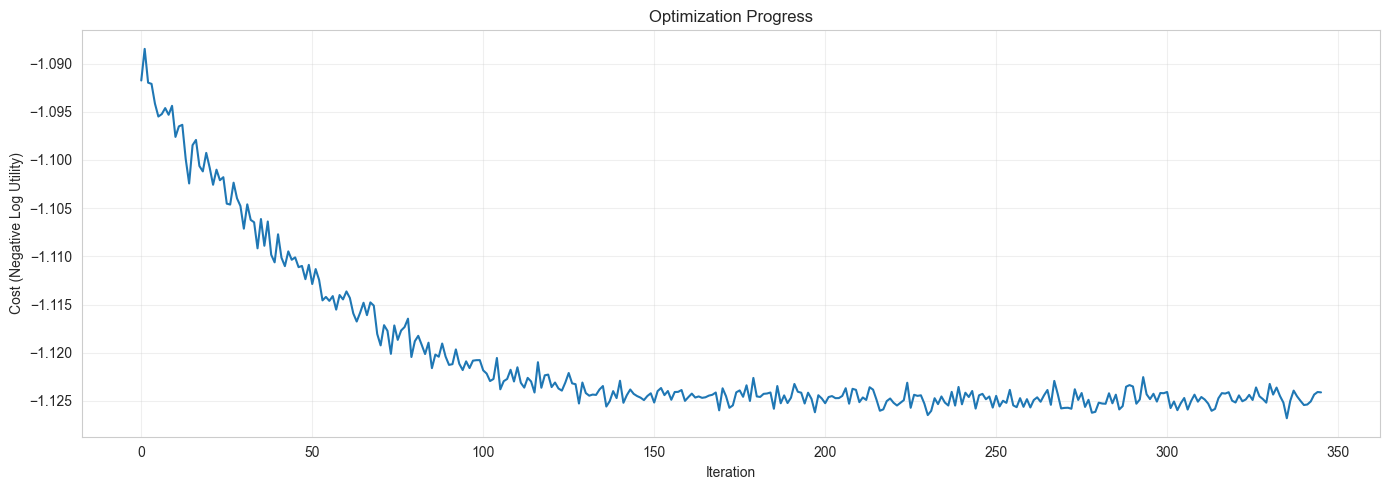

In [9]:
# Plot optimization progress
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(cost_history)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost (Negative Log Utility)')
ax.set_title('Optimization Progress')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

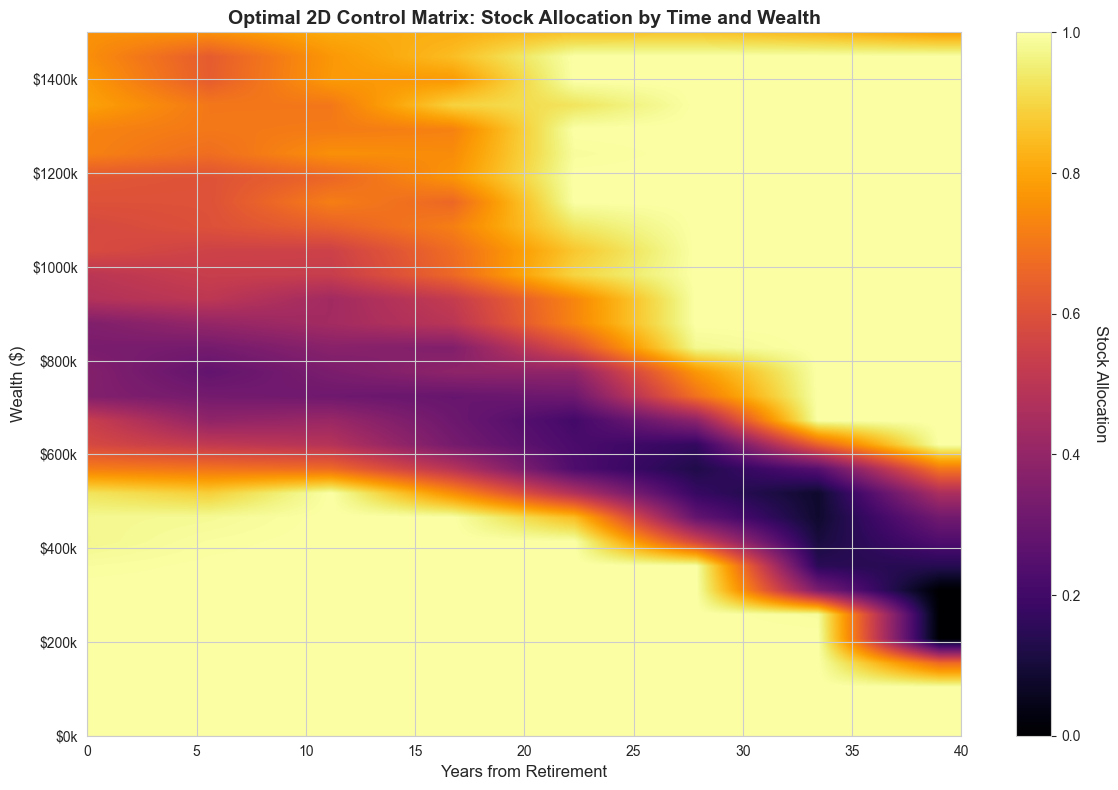


Optimal Control Matrix:
[[1.         1.         1.         1.         1.         1.
  1.         0.9922094  0.9758042  0.97775924 0.9282483  0.7165073
  0.5746658  0.5357789  0.35672483 0.36155698 0.33832812 0.35314137
  0.47845262 0.49930316 0.5816412  0.5764678  0.60145766 0.618578
  0.7247131  0.7283512  0.79459804 0.7769704  0.75342506 0.7585081 ]
 [1.         1.         0.9995703  1.         1.         1.
  1.         0.9982627  0.9930387  0.9824294  0.8846812  0.69329536
  0.5157656  0.3917263  0.32290784 0.2816028  0.32589772 0.40390083
  0.50625795 0.53474617 0.55185086 0.60040164 0.6031388  0.6056071
  0.6777002  0.7044985  0.7022457  0.63624394 0.6318642  0.7558168 ]
 [1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         0.6708922
  0.48528636 0.41642076 0.3100799  0.34004298 0.3746064  0.4383427
  0.43554386 0.53145736 0.54732794 0.6456546  0.71733075 0.65933216
  0.755724   0.7098133  0.70192116 0.77420944 0.771

In [10]:
# Plot optimal control matrix as heatmap
final_matrix = control_matrix.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 8))

# Create fine grid for smooth visualization
time_grid = np.linspace(0, S_TIMESTEPS, 1000)
wealth_grid = np.linspace(0, MAX_WEALTH, 1000)
T_mesh, W_mesh = np.meshgrid(time_grid, wealth_grid)

# Use ControlMatrixPolicy for interpolation
allocation_policy = ControlMatrixPolicy(
    control_matrix=control_matrix,
    n_timesteps=S_TIMESTEPS,
    max_wealth=MAX_WEALTH
)

interpolated_matrix = allocation_policy.get_allocation(
    time_idx=torch.tensor(T_mesh.flatten(), device=DEVICE),
    wealth=torch.tensor(W_mesh.flatten(), device=DEVICE)
).cpu().detach().numpy().reshape(T_mesh.shape)

im = ax.imshow(
    interpolated_matrix,
    aspect='auto',
    extent=[0, S_TIMESTEPS, 0, MAX_WEALTH],
    origin='lower',
    cmap='inferno',
    vmin=0,
    vmax=1
)

# Labels and colorbar
ax.set_xlabel('Years from Retirement', fontsize=12)
ax.set_ylabel('Wealth ($)', fontsize=12)
ax.set_title('Optimal 2D Control Matrix: Stock Allocation by Time and Wealth', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Stock Allocation', rotation=270, labelpad=20, fontsize=12)

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

print("\nOptimal Control Matrix:")
print(final_matrix)

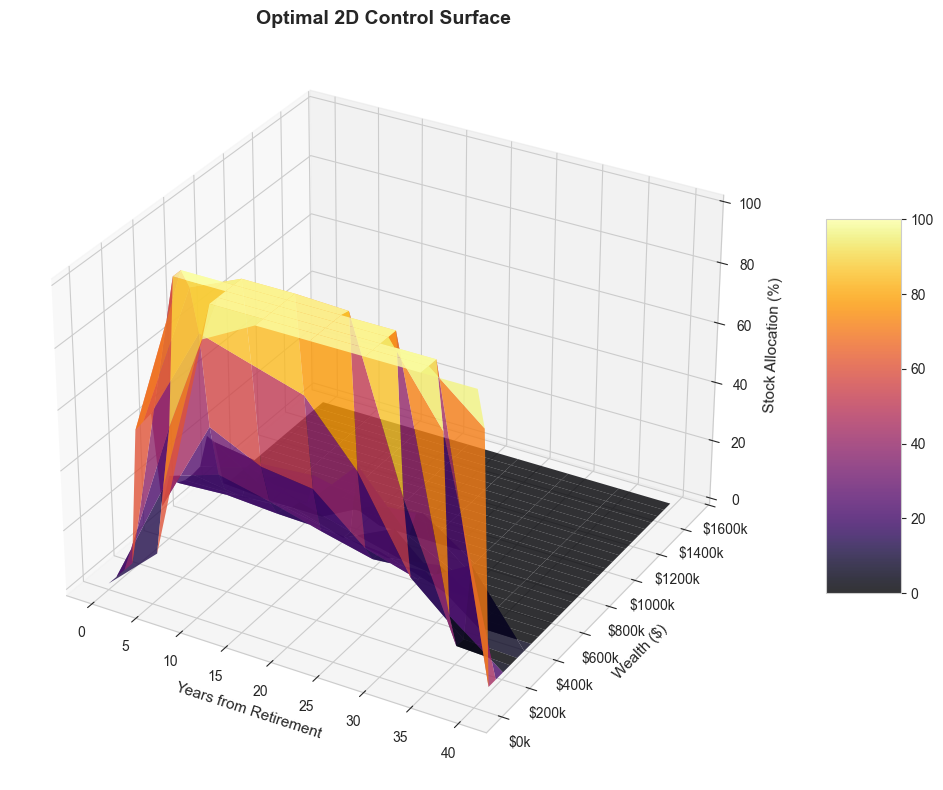

In [12]:
# Plot 3D surface
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid for surface plot
time_grid = np.linspace(0, S_TIMESTEPS, N_TIME_NODES)
wealth_grid = np.linspace(0, MAX_WEALTH, N_WEALTH_NODES)
T_mesh, W_mesh = np.meshgrid(time_grid, wealth_grid)

# Plot surface
surf = ax.plot_surface(
    T_mesh, W_mesh, final_matrix.T * 100,
    cmap='inferno',
    alpha=0.8,
    edgecolor='none'
)

ax.set_xlabel('Years from Retirement', fontsize=11)
ax.set_ylabel('Wealth ($)', fontsize=11)
ax.set_zlabel('Stock Allocation (%)', fontsize=11)
ax.set_title('Optimal 2D Control Surface', fontsize=14, fontweight='bold')

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

## 6. Final Simulation and Analysis

In [ ]:
# Run final simulation with optimal control matrix
with torch.no_grad():
    wealth_final, consumption_final = simulate_wealth_with_control_matrix(
        simulated_returns=mc_returns,
        control_matrix=control_matrix,
        initial_wealth=INITIAL_WEALTH,
        min_consumption_real=MIN_CONSUMPTION_REAL,
        consumption_rate=CONSUMPTION_RATE,
        max_wealth=MAX_WEALTH,
        inflation=INFLATION,  # Pass float, not ConstantInflation object
        real_decline_rate=REAL_DECLINE_RATE,
    )
    
    wealth_final_np = wealth_final.cpu().numpy()
    consumption_final_np = consumption_final.cpu().numpy()

ages = np.arange(65, 65 + S_TIMESTEPS)

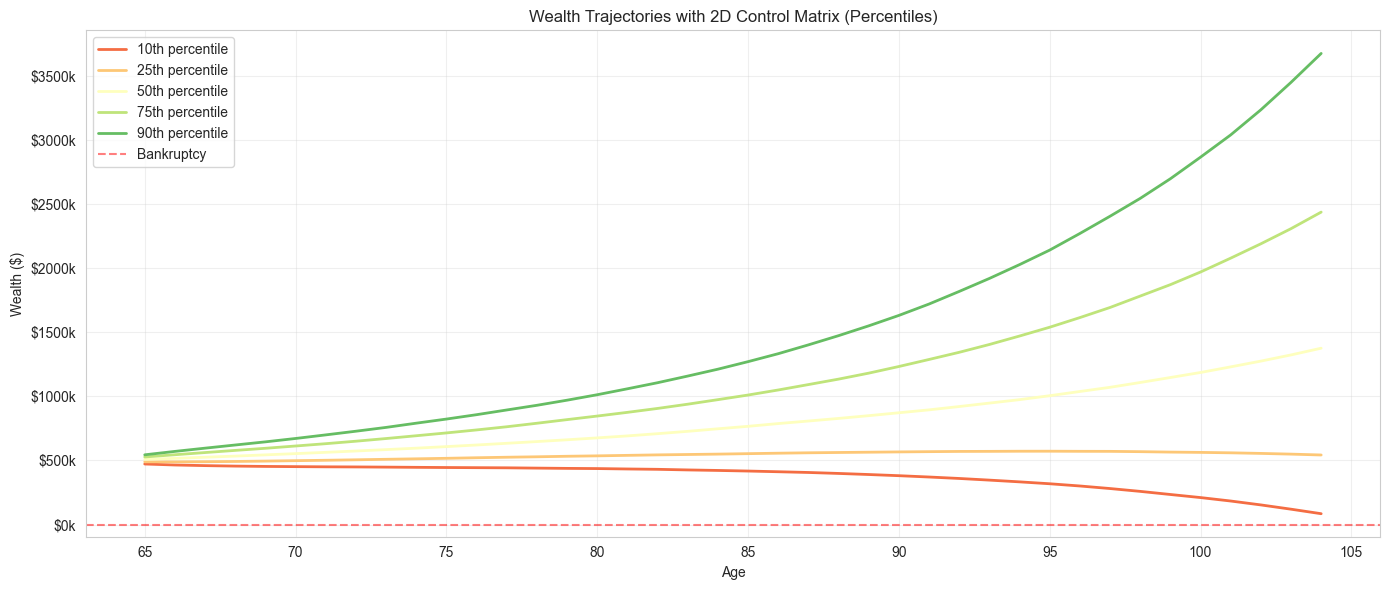

In [14]:
# Plot wealth trajectories
plt.figure(figsize=(14, 6))

percentiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(percentiles)))

for i, p in enumerate(percentiles):
    plt.plot(ages, np.percentile(wealth_final_np[:, 1:], p, axis=0), 
             label=f'{p}th percentile', linewidth=2, color=colors[i])

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Bankruptcy')
plt.xlabel('Age')
plt.ylabel('Wealth ($)')
plt.title('Wealth Trajectories with 2D Control Matrix (Percentiles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

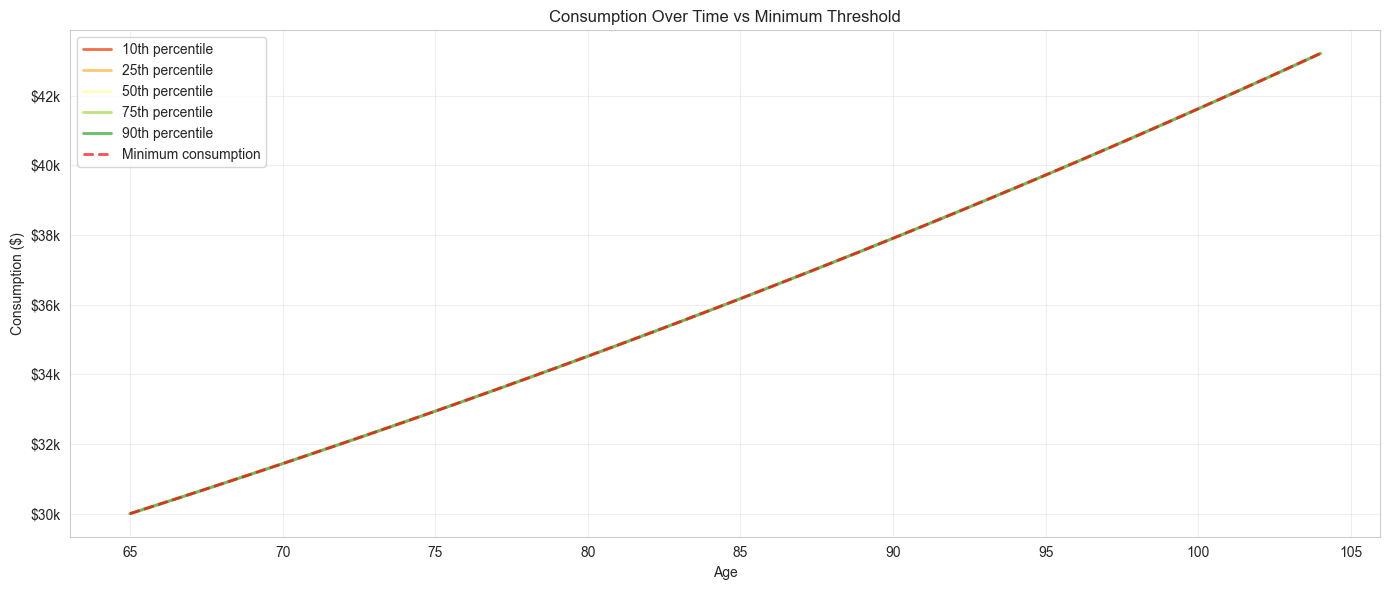

In [15]:
# Plot consumption vs minimum threshold
plt.figure(figsize=(14, 6))

# Calculate minimum consumption nominal values over time
min_consumption_nominal = np.array([
    MIN_CONSUMPTION_REAL * ((1 - REAL_DECLINE_RATE) ** t) * ((1 + INFLATION) ** t)
    for t in range(S_TIMESTEPS)
])

# Plot consumption percentiles
for i, p in enumerate([10, 25, 50, 75, 90]):
    plt.plot(ages, np.percentile(consumption_final_np, p, axis=0),
             label=f'{p}th percentile', linewidth=2, color=colors[i])

# Plot minimum consumption threshold
plt.plot(ages, min_consumption_nominal, 'r--', linewidth=2, label='Minimum consumption', alpha=0.7)

plt.xlabel('Age')
plt.ylabel('Consumption ($)')
plt.title('Consumption Over Time vs Minimum Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

In [16]:
# Summary statistics
print("=" * 60)
print("2D CONTROL MATRIX OPTIMIZATION RESULTS")
print("=" * 60)

print(f"\nControl Matrix Configuration:")
print(f"  Time nodes: {N_TIME_NODES}")
print(f"  Wealth nodes: {N_WEALTH_NODES}")
print(f"  Max wealth bound: ${MAX_WEALTH:,.0f}")
print(f"  Interpolation: Bilinear")

print(f"\nInitial Parameters:")
print(f"  Initial wealth: ${INITIAL_WEALTH:,.0f}")
print(f"  Min consumption (real, year 0): ${MIN_CONSUMPTION_REAL:,.0f}")
print(f"  Consumption rate: {CONSUMPTION_RATE:.1%}")
print(f"  Simulation horizon: {S_TIMESTEPS} years")
print(f"  Number of simulations: {N_SIMULATIONS * BATCHES:,}")

bankruptcy_rate = (wealth_final[:, -1] == 0).sum().item() / (N_SIMULATIONS * BATCHES)
median_terminal_wealth = np.median(wealth_final_np[:, -1])
mean_terminal_wealth = wealth_final_np[:, -1].mean()

print(f"\nOutcome Statistics:")
print(f"  Mean log consumption: {np.log(consumption_final_np + 1e-8).mean():.4f}")
print(f"  Mean consumption: ${consumption_final_np.mean():,.0f}")
print(f"  Median consumption: ${np.median(consumption_final_np):,.0f}")
print(f"  Bankruptcy rate: {bankruptcy_rate:.2%}")
print(f"  Mean terminal wealth: ${mean_terminal_wealth:,.0f}")
print(f"  Median terminal wealth: ${median_terminal_wealth:,.0f}")
print(f"  10th percentile terminal wealth: ${np.percentile(wealth_final_np[:, -1], 10):,.0f}")
print(f"  90th percentile terminal wealth: ${np.percentile(wealth_final_np[:, -1], 90):,.0f}")

print("\n" + "=" * 60)

2D CONTROL MATRIX OPTIMIZATION RESULTS

Control Matrix Configuration:
  Time nodes: 8
  Wealth nodes: 30
  Max wealth bound: $1,500,000
  Interpolation: Bilinear

Initial Parameters:
  Initial wealth: $500,000
  Min consumption (real, year 0): $30,000
  Consumption rate: 0.0%
  Simulation horizon: 40 years
  Number of simulations: 100,000

Outcome Statistics:
  Mean log consumption: 10.0417
  Mean consumption: $35,552
  Median consumption: $35,836
  Bankruptcy rate: 7.14%
  Mean terminal wealth: $1,697,619
  Median terminal wealth: $1,375,866
  10th percentile terminal wealth: $84,940
  90th percentile terminal wealth: $3,675,002



## 7. Save Results

In [17]:
# Save control matrix
np.save('control_matrix_optimal.npy', final_matrix)
print("Saved optimal control matrix to 'control_matrix_optimal.npy'")

# Save summary statistics
summary_stats = pd.DataFrame({
    'Metric': [
        'Mean Terminal Wealth',
        'Median Terminal Wealth',
        '10th Percentile Terminal Wealth',
        '90th Percentile Terminal Wealth',
        'Bankruptcy Rate',
        'Mean Consumption',
        'Mean Log Consumption'
    ],
    'Value': [
        mean_terminal_wealth,
        median_terminal_wealth,
        np.percentile(wealth_final_np[:, -1], 10),
        np.percentile(wealth_final_np[:, -1], 90),
        bankruptcy_rate,
        consumption_final_np.mean(),
        np.log(consumption_final_np + 1e-8).mean()
    ]
})

summary_stats.to_csv('control_matrix_results.csv', index=False)
print("Saved summary statistics to 'control_matrix_results.csv'")

Saved optimal control matrix to 'control_matrix_optimal.npy'
Saved summary statistics to 'control_matrix_results.csv'
